In [ ]:
# ======================
# IMPORT LIBRARIES
# ======================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

from sqlalchemy import create_engine


# Display Settings
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ======================
# LOAD DATASET
# ======================

file_path = "C:\\Users\\Sahil\\Documents\\MY PROJECTS\\AI-Retail-Intelligence-System\\data\\raw\\retail_store_inventory.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,01-01-2022,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,01-01-2022,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,01-01-2022,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,01-01-2022,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,01-01-2022,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [3]:
# ======================
# DATASET OVERVIEW
# ======================

print("="*50)
print("DATASET SHAPE")
print("="*50)

print(df.shape)

print("\n")

print("="*50)
print("DATASET INFO")
print("="*50)

print(df.info())

print("\n")

print("="*50)
print("STATISTICAL SUMMARY")
print("="*50)

df.describe()

DATASET SHAPE
(73100, 15)


DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  str    
 1   Store ID            73100 non-null  str    
 2   Product ID          73100 non-null  str    
 3   Category            73100 non-null  str    
 4   Region              73100 non-null  str    
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  str    
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  str    
dtypes: float64(3), int64(5)

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [4]:
# ======================
# COLUMN STANDARDIZATION
# ======================

df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
    .str.replace('/', '_')
)

print("Updated Columns:\n")

for col in df.columns:
    print(col)

Updated Columns:

date
store_id
product_id
category
region
inventory_level
units_sold
units_ordered
demand_forecast
price
discount
weather_condition
holiday_promotion
competitor_pricing
seasonality


In [5]:
# ======================
# DATE CONVERSION
# ======================

df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

print(df['date'].dtype)

print(df['date'].dtype)

datetime64[us]
datetime64[us]


In [6]:
# ======================
# MISSING VALUE ANALYSIS
# ======================

missing_values = df.isnull().sum()

print(missing_values)

# Fill Missing Values
df.ffill(inplace=True)

print("\nMissing Values Handled Successfully")

date                  0
store_id              0
product_id            0
category              0
region                0
inventory_level       0
units_sold            0
units_ordered         0
demand_forecast       0
price                 0
discount              0
weather_condition     0
holiday_promotion     0
competitor_pricing    0
seasonality           0
dtype: int64

Missing Values Handled Successfully


In [7]:
# ======================
# DUPLICATE REMOVAL
# ======================

before_duplicates = df.shape[0]

df.drop_duplicates(inplace=True)

after_duplicates = df.shape[0]

removed_duplicates = before_duplicates - after_duplicates

print(f"Removed Duplicates: {removed_duplicates}")

Removed Duplicates: 0


In [8]:
# ======================
# REMOVE NEGATIVE DEMAND FORECAST
# ======================

df = df[df['demand_forecast'] >= 0]

print("Negative Demand Forecast Removed")

Negative Demand Forecast Removed


In [9]:
# ======================
# FEATURE ENGINEERING
# ======================

# Revenue
df['revenue'] = (
    df['units_sold'] * df['price']
)

# Estimated Profit
df['estimated_profit'] = (
    df['revenue'] * 0.25
)

# Demand Gap
df['demand_gap'] = (
    df['demand_forecast'] - df['units_sold']
)

# Price Difference
df['price_difference'] = (
    df['price'] - df['competitor_pricing']
)

# Stock Turnover
df['stock_turnover'] = (
    df['units_sold'] / df['inventory_level']
)

# Inventory Risk
df['inventory_risk'] = np.where(
    df['inventory_level'] < df['units_sold'],
    'Low Stock',
    'Normal'
)

print("Feature Engineering Completed")

Feature Engineering Completed


In [10]:
# ======================
# INVENTORY RISK CLASSIFICATION
# ======================

conditions = [

    df['inventory_level'] < (
        df['demand_forecast'] * 0.7
    ),

    (
        (df['inventory_level'] >= (
            df['demand_forecast'] * 0.7
        ))

        &

        (df['inventory_level'] < (
            df['demand_forecast'] * 1.2
        ))
    )

]

choices = [
    'Critical Stock',
    'Low Stock'
]

df['inventory_risk'] = np.select(
    conditions,
    choices,
    default='Normal'
)

print("Inventory Risk Classification Completed")

Inventory Risk Classification Completed


In [11]:
# ======================
# DATE FEATURES
# ======================

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.day_name()
df['quarter'] = df['date'].dt.quarter

print("Date Features Created")

Date Features Created


In [12]:
# ======================
# BUSINESS KPIs
# ======================

# Total Revenue
total_revenue = df['revenue'].sum()

# Total Profit
total_profit = df['estimated_profit'].sum()

# Average Sales
average_sales = df['units_sold'].mean()

# Total Inventory
total_inventory = df['inventory_level'].sum()

print("="*50)
print("BUSINESS KPI SUMMARY")
print("="*50)

print(f"Total Revenue      : {total_revenue:,.2f}")
print(f"Total Profit       : {total_profit:,.2f}")
print(f"Average Units Sold : {average_sales:.2f}")
print(f"Total Inventory    : {total_inventory:,}")

BUSINESS KPI SUMMARY
Total Revenue      : 550,118,851.12
Total Profit       : 137,529,712.78
Average Units Sold : 137.71
Total Inventory    : 19,929,382


In [13]:
# ======================
# CATEGORY PERFORMANCE
# ======================

category_performance = (
    df.groupby('category')
    ['revenue']
    .sum()
    .sort_values(ascending=False)
)

print(category_performance)

category
Furniture      1.114889e+08
Groceries      1.109621e+08
Clothing       1.096317e+08
Toys           1.096177e+08
Electronics    1.084184e+08
Name: revenue, dtype: float64


In [14]:
# ======================
# REGIONAL ANALYSIS
# ======================

regional_analysis = (
    df.groupby('region')
    ['revenue']
    .sum()
    .sort_values(ascending=False)
)

print(regional_analysis)

region
East     1.386788e+08
South    1.384561e+08
North    1.372320e+08
West     1.357521e+08
Name: revenue, dtype: float64


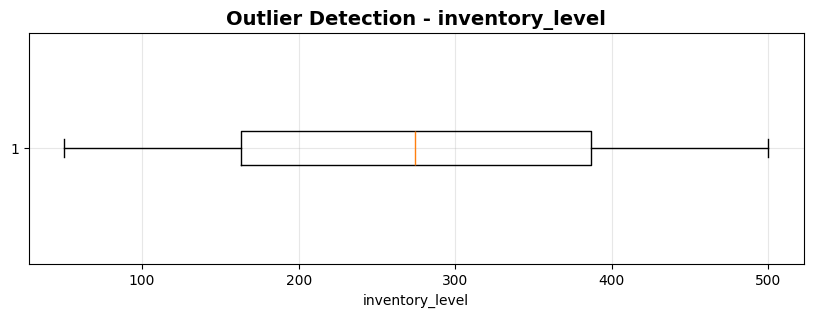

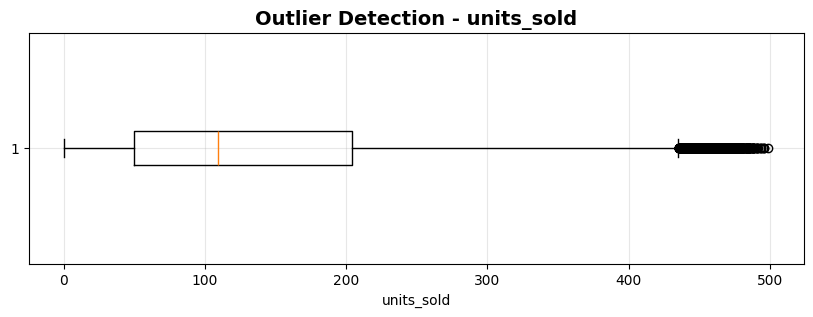

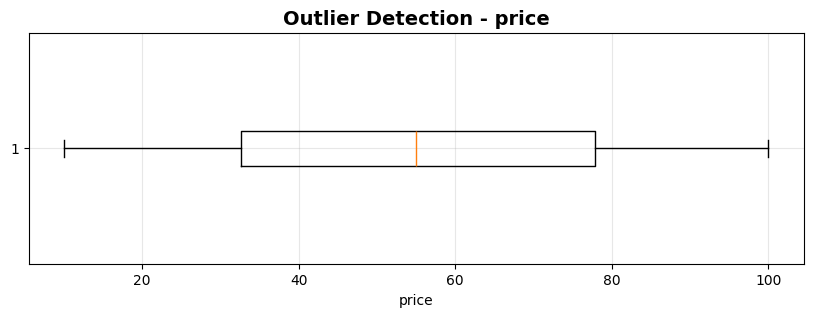

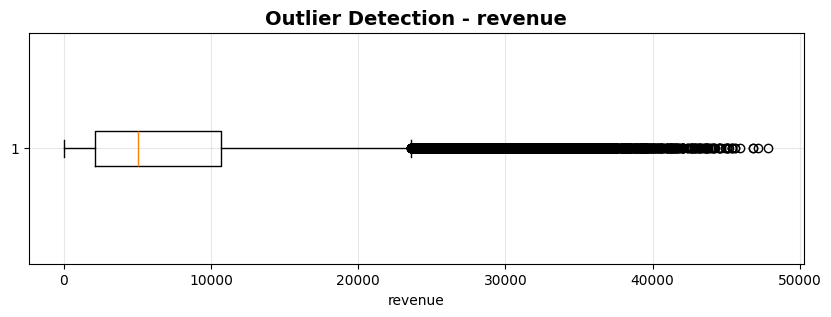

In [15]:
# ======================
# OUTLIER DETECTION
# ======================

numeric_columns = [
    'inventory_level',
    'units_sold',
    'price',
    'revenue'
]

for col in numeric_columns:

    plt.figure(figsize=(10,3))

    plt.boxplot(
        df[col],
        vert=False
    )

    plt.title(
        f'Outlier Detection - {col}',
        fontsize=14,
        fontweight='bold'
    )

    plt.xlabel(col)

    plt.grid(alpha=0.3)

    plt.show()

# Outlier Analysis Interpretation

The dataset contains several high-value observations in:
- Units Sold
- Revenue

These outliers likely represent:
- Seasonal demand spikes
- Promotional campaigns
- High-performing products
- Bulk purchases

Since this is a retail business dataset, these values are considered meaningful business behavior rather than data errors.

Therefore:
- Extreme business values are retained
- No aggressive outlier removal was performed
- This preserves forecasting and pricing intelligence

In [16]:
# ======================
# SAVE CLEANED DATASET
# ======================

output_path = "C:\\Users\\Sahil\\Documents\\MY PROJECTS\\AI-Retail-Intelligence-System\\data\\cleaned\\retail_cleaned.csv"

df.to_csv(output_path, index=False)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully


In [17]:
# ================================
# DATABASE CONNECTION TEST
# ================================

username = "postgres"
password = "1234"
host = "localhost"
port = "5432"
database = "retail_ai_system"

try:

    engine = create_engine(
        f'postgresql://{username}:{password}@{host}:{port}/{database}'
    )

    connection = engine.connect()

    print("PostgreSQL Connected Successfully")

    connection.close()

except Exception as e:

    print("Database Connection Failed")

    print(e)

PostgreSQL Connected Successfully


In [18]:
# ======================
# UPLOAD DATA TO POSTGRESQL
# ======================

df.to_sql(
    'retail_inventory',
    engine,
    if_exists='replace',
    index=False
)

print("Dataset Uploaded Successfully")

Dataset Uploaded Successfully


In [19]:
# ======================
# FINAL DATASET PREVIEW
# ======================

print(df.head())

print("\n")

print(df.columns)

        date store_id product_id     category region  inventory_level  \
0 2022-01-01     S001      P0001    Groceries  North              231   
1 2022-01-01     S001      P0002         Toys  South              204   
2 2022-01-01     S001      P0003         Toys   West              102   
3 2022-01-01     S001      P0004         Toys  North              469   
4 2022-01-01     S001      P0005  Electronics   East              166   

   units_sold  units_ordered  demand_forecast  price  discount  \
0         127             55           135.47  33.50        20   
1         150             66           144.04  63.01        20   
2          65             51            74.02  27.99        10   
3          61            164            62.18  32.72        10   
4          14            135             9.26  73.64         0   

  weather_condition  holiday_promotion  competitor_pricing seasonality  \
0             Rainy                  0               29.69      Autumn   
1             Su

# Project Summary

This notebook completed:
- Data cleaning
- Missing value handling
- Duplicate removal
- Business validation
- Feature engineering
- Inventory intelligence
- KPI generation
- Outlier analysis
- PostgreSQL integration

The cleaned dataset is now:
- Analytics-ready
- Dashboard-ready
- Machine learning-ready
- Enterprise-ready